***Comparision of MODELS***

Comparision of

1.Logistic Regression

2.SVM(Support Vector Machine)

3.RandomForest

4.KNN

5.XGBoost

Five classification models were trained and evaluated on the underwater acoustic dataset to identify the best candidate for hyperparameter tuning and deployment: Logistic Regression, Support Vector Machine (SVM), Random Forest, K-Nearest Neighbours (KNN), and XGBoost. This report summarizes overall performance, a detailed per-class comparison of the two leading models, and the rationale for the final selection.

**Overall Model Performance**


The table below reports overall Accuracy, Precision, Recall, and F1 Score (weighted) for all five models on the held-out test set.

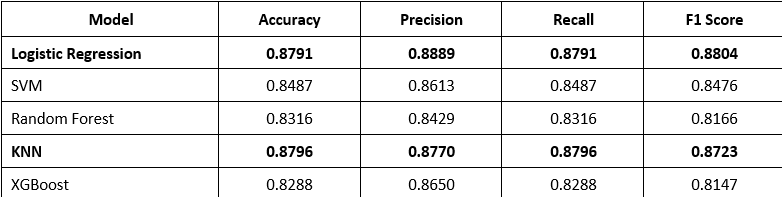


Logistic Regression and KNN are effectively tied at the top and clearly ahead of the remaining three models. SVM sits roughly 3 points behind the leaders on every metric. Random Forest and XGBoost trail the pack, and notably their F1 scores drop more than their accuracy does relative to the leaders — a sign that these two models are performing worse on harder or minority classes even though overall accuracy looks reasonable. Both were run with default hyperparameters, so some of this gap may close with tuning, but neither was competitive enough at baseline to prioritize over the top two.

**Model notes**

●	Logistic Regression – A linear model; fast to train, cheap to tune, and interpretable via feature coefficients. Best F1 (0.8804) and Precision (0.8889) among all five models.

●	Support Vector Machine – Kernel-based; moderate performance, more expensive to tune (kernel choice, C, gamma) than the top two.

●	Random Forest – Ensemble of trees; underperformed at default settings, largest gap between accuracy and F1.

●	K-Nearest Neighbours – Instance-based, no real training phase; best Accuracy (0.8796) and Recall (0.8796), but sensitive to feature scaling and the curse of dimensionality at inference time.

●	XGBoost – Gradient-boosted trees; weakest F1 of the five at default settings, though it typically has meaningful headroom after tuning.


**Detailed Comparison: KNN vs. Logistic Regression**

Since KNN and Logistic Regression were statistically close on aggregate metrics, per-class precision, recall, and F1 were examined to make an informed final choice. The dataset has three classes: Ambience (n=360), Biological (n=500), and Vessels (n=951).

KNN - per class report

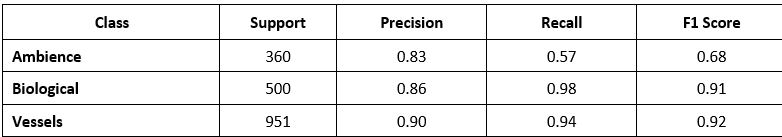

KNN - Confusion Matrix

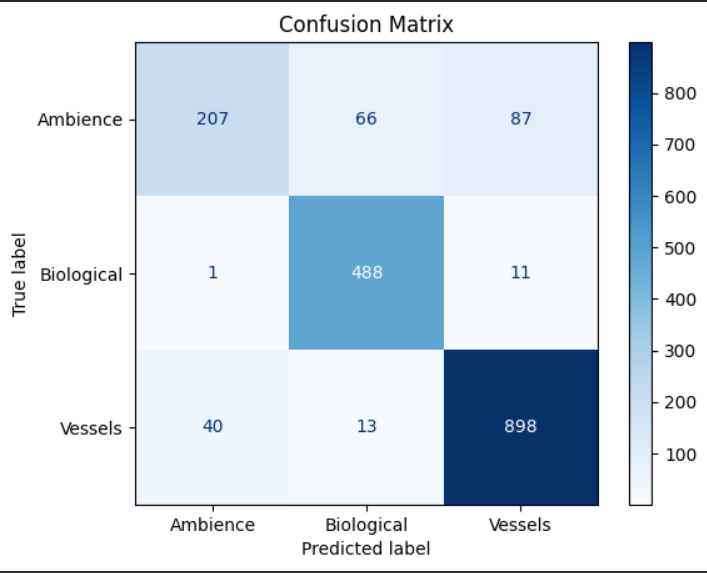

Key Observations

Strengths:

Biological sounds are classified with very high recall (97.6%).
Vessel sounds are also recognized accurately with 94.4% recall.
Most predictions lie along the diagonal, indicating strong overall classification performance.

Weaknesses:

The major source of error is:

Ambience → Vessels = 87
Ambience → Biological = 66

Unlike your Logistic Regression model, this model struggles to distinguish Ambience recordings, although it performs substantially better on Biological and Vessel classes.

Logistic Regression – per-class report

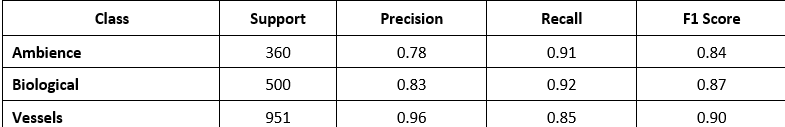

Logistic Refression - Confusion Matrix

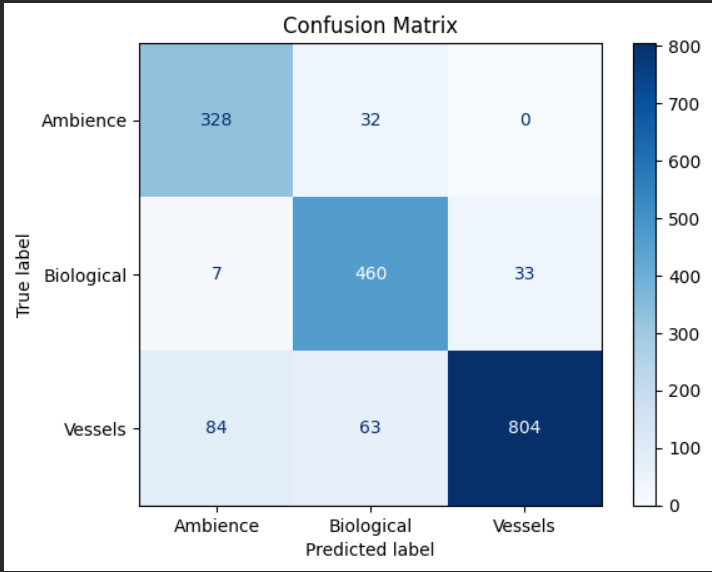

Overall Observations

Strengths:

Most predictions lie on the diagonal, indicating correct classifications.
Biological has the highest class-wise accuracy (~92%).

Ambience is also recognized well (~91%).
There is no confusion between Ambience and Vessels in one direction (Ambience → Vessels = 0).

Weaknesses

The largest source of error is:

Vessels → Ambience = 84
Vessels → Biological = 63
Biological → Vessels = 33

This suggests that the features extracted from some Vessel recordings are similar to those of the other two classes.

Key observation – the Ambience class

The per-class breakdown reveals the deciding factor. KNN’s recall on the Ambience class is only 0.57, meaning it correctly identifies barely more than half of true Ambience samples — the rest are misclassified, most likely absorbed into the Biological class, whose recall is a suspiciously high 0.98. This is a meaningful weakness for an underwater acoustic classifier, since confusing background/ambient noise with a genuine biological or vessel signal is an operationally costly error (false alarms or missed context).

Logistic Regression trades a small amount of Ambience precision (0.78 vs. 0.83) for a much stronger Ambience recall (0.91 vs. 0.57), raising Ambience F1 from 0.68 to 0.84. It gives up some Vessels recall (0.85 vs. 0.94) in exchange for a notable gain in Vessels precision (0.96 vs. 0.90). The net effect is a macro F1 of 0.87 versus 0.84 for KNN — a more balanced classifier across all three classes rather than one that is mainly riding the majority Vessels class (951 of 1811 samples) to a good weighted score.


Why Logistic Regression Was Selected

●	Best macro F1 (0.87 vs. 0.84) – reflects better performance across all classes, not only the majority class.

●	Fixes KNN’s primary failure mode – Ambience recall improves from 0.57 to 0.91, directly addressing the weakest point in the per-class results.

●	Cheaper and faster to tune – a small hyperparameter space (C, penalty, solver) compared to KNN’s k, distance metric, and weighting scheme.

●	More interpretable – coefficients can be inspected to understand which acoustic features drive each class decision.

●	Scales better at inference – unlike KNN, which requires distance computation against the full training set at prediction time and is more vulnerable to the curse of dimensionality on high-dimensional acoustic feature vectors (e.g., MFCCs, spectral features).

Based on this analysis, Logistic Regression is selected as the model to carry forward for hyperparameter tuning.
